# Data Mining Project — Checkpoint 1

**Author:** Ahad Hussain (535007416)  
**Course:** CSCE 676 - Data Mining and Analysis  
**Date:** Spring 2026

This notebook covers Checkpoint 1 requirements: candidate dataset identification (A), comparative analysis (B), dataset selection (C), exploratory data analysis (D), initial insights (E), and GitHub portfolio (F).

**Selected Dataset:** Instacart Online Grocery Shopping Dataset 2017

---

## Collaboration Declaration

On my honor, I declare the following resources:

**1. Collaborators:** None

**2. Web Sources:**
- https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis - Instacart dataset documentation
- https://grouplens.org/datasets/movielens/25m/ - MovieLens 25M dataset page and license
- https://www.yelp.com/dataset/documentation/main - Yelp Open Dataset documentation (may block automated access)
- https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset - Mirror download & overview (Kaggle)
- https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/fpgrowth/ - FP-Growth documentation

**3. AI Tools:** Claude (used for notebook restructuring, ensuring claims are evidence-backed, and code optimization; all code executed and results verified by the author).

**4. Paper Citations:** None for this checkpoint.

---

### Dataset License Summary

| Dataset | License | Key Restrictions |
|---------|---------|------------------|
| Instacart | Kaggle Competition Terms | Do not redistribute; academic use OK |
| MovieLens | GroupLens Research License | Non-commercial; do not redistribute |
| Yelp | Yelp Dataset Terms of Use (July 2023) | **Academic use only**; 12-month term; no commercial use; no redistribution; must submit findings to Yelp for approval before publication |

**Yelp License Notes:** Per Section 3 of the Yelp Dataset Terms, use is limited to "academic use" meaning use by "registered nonprofits, government, educational institutions, and think tanks which (a) is not undertaken for profit, or (b) is not intended to produce works, services, or data for commercial use." This coursework qualifies as academic use.

## Setup and Data Paths

Due to dataset size (32M+ rows for Instacart, 25M+ ratings for MovieLens 25M, 5GB+ for Yelp), this notebook loads samples of up to 1M rows for initial exploration. Full-scale analysis in later checkpoints will use chunked processing.

In [78]:
# Core imports
import os
import json
import tarfile
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# -----------------------------
# Display helpers (Markdown-first)
# -----------------------------
def md(text: str):
    """Render Markdown in the notebook."""
    display(Markdown(text))

def md_table(df: pd.DataFrame, title: str | None = None):
    """Render a pandas DataFrame as a Markdown table (readable in notebooks)."""
    if title:
        md(f"**{title}**")
    # Keep tables readable: limit extremely wide tables by truncating columns if needed
    display(Markdown(df.to_markdown(index=False)))

def kv(mapping: dict, title: str | None = None):
    """Render key/value pairs as a compact Markdown table."""
    df = pd.DataFrame({"Metric": list(mapping.keys()), "Value": list(mapping.values())})
    md_table(df, title=title)

# -----------------------------
# Dataset paths - UPDATE THESE TO YOUR LOCAL PATHS
# -----------------------------
INSTACART_DIR = Path("instacart-online-grocery-basket-analysis-dataset")
MOVIELENS_DIR = Path("ml-latest")
YELP_TAR = Path("Yelp JSON/yelp_dataset.tar")  # Yelp comes as a .tar archive

# Sample size for initial exploration (feasibility + quick EDA)
SAMPLE_ROWS = 1_000_000
md(f"Sample size for exploration: **{SAMPLE_ROWS:,} rows**")


Sample size for exploration: **1,000,000 rows**

---
# (A) Identification of Candidate Datasets

Each candidate aligns with at least one **course topic** and one **beyond-course technique**. This section profiles all three datasets before selection.

## A.1 — Dataset Overview and Scale

First, we examine what data is available and its scale to understand feasibility constraints.

In [79]:
# Utilities: dataset file inspection (Markdown outputs)

def get_file_info(filepath: Path):
    """Get file existence + size (MB) + optional line count (for CSV) without loading."""
    filepath = Path(filepath)
    if not filepath.exists():
        return {"file": filepath.name, "exists": False, "size_mb": None, "lines": None}

    size_mb = filepath.stat().st_size / (1024 * 1024)
    lines = None

    if filepath.suffix.lower() == ".csv":
        # Line counts can be slow for huge files; keep it best-effort.
        try:
            with open(filepath, "rb") as f:
                lines = sum(1 for _ in f) - 1  # subtract header
        except Exception:
            lines = "n/a"

    return {"file": filepath.name, "exists": True, "size_mb": round(size_mb, 2), "lines": lines}

def summarize_directory_files(title: str, base_dir: Path, files: list[str]):
    base_dir = Path(base_dir)
    rows = []
    for f in files:
        rows.append(get_file_info(base_dir / f))

    df = pd.DataFrame(rows)
    df["size_mb"] = df["size_mb"].fillna(0.0)
    total_mb = df["size_mb"].sum()

    md(f"## {title}")
    md_table(
        df.assign(size_mb=df["size_mb"].round(2)).replace({True: "yes", False: "no"}),
        title="Files on disk",
    )
    kv({"total size (MB)": f"{total_mb:.2f}", "total size (GB)": f"{total_mb/1024:.2f}"}, title="Size summary")

def summarize_tar_archive(title: str, tar_path: Path, preview_n: int = 12):
    tar_path = Path(tar_path)
    md(f"## {title}")

    if not tar_path.exists():
        md(f"**Status:** ❌ archive not found at `{tar_path}`")
        return

    size_mb = tar_path.stat().st_size / (1024 * 1024)
    kv({"archive size (MB)": f"{size_mb:.2f}", "archive size (GB)": f"{size_mb/1024:.2f}"}, title="Archive size")

    # Preview contents (best effort)
    try:
        with tarfile.open(tar_path, "r") as tar:
            members = [m for m in tar.getmembers() if m.isfile()]
            preview = []
            for m in members[:preview_n]:
                preview.append({"path": m.name, "size_mb": round(m.size / (1024 * 1024), 2)})
            md_table(pd.DataFrame(preview), title=f"Archive contents preview (first {min(preview_n, len(members))} files)")
            if len(members) > preview_n:
                md(f"_… and {len(members) - preview_n} more files_")
    except Exception as e:
        md(f"⚠️ Could not read tar contents preview: `{e}`")


## A.2 — Schema and Structure

Loading samples (up to 1M rows) to examine data types, relationships, and structure.

In [80]:
# ============================================================
# INSTACART: Load data (full + sample) and summarize
# ============================================================
md("## A.1 — Candidate Dataset 1: Instacart (Retail Transactions)")

instacart_orders = pd.read_csv(INSTACART_DIR / "orders.csv")
instacart_prior_sample = pd.read_csv(INSTACART_DIR / "order_products__prior.csv", nrows=SAMPLE_ROWS)
instacart_products = pd.read_csv(INSTACART_DIR / "products.csv")
instacart_aisles = pd.read_csv(INSTACART_DIR / "aisles.csv")
instacart_departments = pd.read_csv(INSTACART_DIR / "departments.csv")

kv({
    "orders.csv rows (full)": f"{len(instacart_orders):,}",
    "order_products__prior.csv rows (sample)": f"{len(instacart_prior_sample):,}",
    "products.csv rows": f"{len(instacart_products):,}",
    "aisles.csv rows": f"{len(instacart_aisles):,}",
    "departments.csv rows": f"{len(instacart_departments):,}",
}, title="Loaded tables")

# Quick schema peek (first 3 rows each)
md("**Schema peek (first 3 rows)**")
md_table(instacart_orders.head(3))
md_table(instacart_prior_sample.head(3))
md_table(instacart_products.head(3))

## A.1 — Candidate Dataset 1: Instacart (Retail Transactions)

**Loaded tables**

| Metric                                  | Value     |
|:----------------------------------------|:----------|
| orders.csv rows (full)                  | 3,421,083 |
| order_products__prior.csv rows (sample) | 1,000,000 |
| products.csv rows                       | 49,688    |
| aisles.csv rows                         | 134       |
| departments.csv rows                    | 21        |

**Schema peek (first 3 rows)**

|   order_id |   user_id | eval_set   |   order_number |   order_dow |   order_hour_of_day |   days_since_prior_order |
|-----------:|----------:|:-----------|---------------:|------------:|--------------------:|-------------------------:|
|    2539329 |         1 | prior      |              1 |           2 |                   8 |                      nan |
|    2398795 |         1 | prior      |              2 |           3 |                   7 |                       15 |
|     473747 |         1 | prior      |              3 |           3 |                  12 |                       21 |

|   order_id |   product_id |   add_to_cart_order |   reordered |
|-----------:|-------------:|--------------------:|------------:|
|          2 |        33120 |                   1 |           1 |
|          2 |        28985 |                   2 |           1 |
|          2 |         9327 |                   3 |           0 |

|   product_id | product_name                         |   aisle_id |   department_id |
|-------------:|:-------------------------------------|-----------:|----------------:|
|            1 | Chocolate Sandwich Cookies           |         61 |              19 |
|            2 | All-Seasons Salt                     |        104 |              13 |
|            3 | Robust Golden Unsweetened Oolong Tea |         94 |               7 |

In [81]:
# ============================================================
# MOVIELENS: Load sample and summarize (Text / Recommender-style)
# ============================================================
md("## A.2 — Candidate Dataset 2: MovieLens 25M (Ratings / Recommenders)")

movielens_ratings_path = MOVIELENS_DIR / "ratings.csv"
movielens_movies_path = MOVIELENS_DIR / "movies.csv"

# Load a sample of ratings for feasibility checks (full file is large)
movielens_ratings_sample = pd.read_csv(movielens_ratings_path, nrows=SAMPLE_ROWS)
movielens_movies = pd.read_csv(movielens_movies_path)

kv({
    "ratings.csv rows (sample)": f"{len(movielens_ratings_sample):,}",
    "movies.csv rows": f"{len(movielens_movies):,}",
    "unique users in sample": f"{movielens_ratings_sample['userId'].nunique():,}",
    "unique movies in sample": f"{movielens_ratings_sample['movieId'].nunique():,}",
}, title="Loaded tables")

# Rating distribution (compact)
rating_dist = (
    movielens_ratings_sample["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)
rating_dist["pct"] = (rating_dist["count"] / rating_dist["count"].sum() * 100).round(2)
md("**Ratings distribution (sample)**")
md_table(rating_dist)


## A.2 — Candidate Dataset 2: MovieLens 25M (Ratings / Recommenders)

**Loaded tables**

| Metric                    | Value     |
|:--------------------------|:----------|
| ratings.csv rows (sample) | 1,000,000 |
| movies.csv rows           | 86,537    |
| unique users in sample    | 9,561     |
| unique movies in sample   | 25,825    |

**Ratings distribution (sample)**

|   rating |   count |   pct |
|---------:|--------:|------:|
|      0.5 |   16710 |  1.67 |
|      1   |   30187 |  3.02 |
|      1.5 |   17407 |  1.74 |
|      2   |   64576 |  6.46 |
|      2.5 |   55010 |  5.5  |
|      3   |  191422 | 19.14 |
|      3.5 |  135650 | 13.56 |
|      4   |  257554 | 25.76 |
|      4.5 |   91903 |  9.19 |
|      5   |  139581 | 13.96 |

In [82]:
# ============================================================
# YELP: Load small sample from JSON (Text + Graph opportunities)
# ============================================================
md("## A.3 — Candidate Dataset 3: Yelp Open Dataset (Reviews / Business Graph)")

# Yelp downloads as a .tar archive (JSON-lines files inside). We:
# 1) extract (once) if needed, 2) locate the JSON files, 3) read a small sample for feasibility.
yelp_sample_rows = 200_000  # keep small — Yelp is large

def ensure_yelp_extracted(yelp_tar: Path, extract_dir: Path) -> Path:
    """Return a directory containing yelp_academic_dataset_*.json (extracting tar if needed)."""
    extract_dir = Path(extract_dir)
    # If already extracted, reuse
    if (extract_dir / "yelp_academic_dataset_review.json").exists():
        return extract_dir

    if not yelp_tar.exists():
        raise FileNotFoundError(f"Yelp tar not found at: {yelp_tar}. Update YELP_TAR near the top of the notebook.")

    extract_dir.mkdir(parents=True, exist_ok=True)
    with tarfile.open(yelp_tar, "r:*") as tar:
        tar.extractall(path=extract_dir)

    # Some tars contain a nested folder; find the directory that actually holds the json files
    candidates = [extract_dir] + [p for p in extract_dir.rglob("*") if p.is_dir()]
    for d in candidates:
        if (d / "yelp_academic_dataset_review.json").exists():
            return d

    raise FileNotFoundError(
        "Extracted Yelp tar, but could not find yelp_academic_dataset_review.json under: " + str(extract_dir)
    )

def read_jsonl_sample(path: Path, nrows: int) -> pd.DataFrame:
    """Read first nrows from JSON-lines file."""
    return pd.read_json(path, lines=True, nrows=nrows)

# Extract (if needed) and resolve base dir
YELP_EXTRACT_DIR = YELP_TAR.parent / "_yelp_extracted"
yelp_base = ensure_yelp_extracted(YELP_TAR, YELP_EXTRACT_DIR)

reviews_path = yelp_base / "yelp_academic_dataset_review.json"
business_path = yelp_base / "yelp_academic_dataset_business.json"
users_path = yelp_base / "yelp_academic_dataset_user.json"

yelp_reviews_sample = read_jsonl_sample(reviews_path, nrows=min(50_000, yelp_sample_rows))
yelp_business_sample = read_jsonl_sample(business_path, nrows=10_000)
yelp_users_sample = read_jsonl_sample(users_path, nrows=10_000)

kv(
    {
        "Reviews sample rows": len(yelp_reviews_sample),
        "Business sample rows": len(yelp_business_sample),
        "Users sample rows": len(yelp_users_sample),
        "Yelp base dir": str(yelp_base),
    },
    title="Yelp sample loaded",
)

md_table(yelp_reviews_sample.head(3))

## A.3 — Candidate Dataset 3: Yelp Open Dataset (Reviews / Business Graph)

**Yelp sample loaded**

| Metric               | Value                     |
|:---------------------|:--------------------------|
| Reviews sample rows  | 50000                     |
| Business sample rows | 10000                     |
| Users sample rows    | 10000                     |
| Yelp base dir        | Yelp JSON/_yelp_extracted |

| review_id              | user_id                | business_id            |   stars |   useful |   funny |   cool | text                                                                                                                                                                                                                                                                                                                                                                                                                                 | date                |
|:-----------------------|:-----------------------|:-----------------------|--------:|---------:|--------:|-------:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------|
| KU_O5udG6zpxOg-VcAEodg | mh_-eMZ6K5RLWhZyISBhwA | XQfwVwDr-v0ZS3_CbbE5Xw |       3 |        0 |       0 |      0 | If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience.                                                                                                                                                                                              | 2018-07-07 22:09:11 |
|                        |                        |                        |         |          |         |        |                                                                                                                                                                                                                                                                                                                                                                                                                                      |                     |
|                        |                        |                        |         |          |         |        | The food is good, but it takes a very long time to come out. The waitstaff is very young, but usually pleasant. We have just had too many experiences where we spent way too long waiting. We usually opt for another diner or restaurant on the weekends, in order to be done quicker.                                                                                                                                              |                     |
| BiTunyQ73aT9WBnpR9DZGw | OyoGAe7OKpv6SyGZT5g77Q | 7ATYjTIgM3jUlt4UM3IypQ |       5 |        1 |       0 |      1 | I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every class is a top notch work out.                                                                                                                                                                                                  | 2012-01-03 15:28:18 |
|                        |                        |                        |         |          |         |        |                                                                                                                                                                                                                                                                                                                                                                                                                                      |                     |
|                        |                        |                        |         |          |         |        | For anyone who struggles to fit workouts in, the online scheduling system makes it easy to plan ahead (and there's no need to line up way in advanced like many gyms make you do).                                                                                                                                                                                                                                                   |                     |
|                        |                        |                        |         |          |         |        |                                                                                                                                                                                                                                                                                                                                                                                                                                      |                     |
|                        |                        |                        |         |          |         |        | There is no way I can write this review without giving Russell, the owner of Body Cycle, a shout out. Russell's passion for fitness and cycling is so evident, as is his desire for all of his clients to succeed. He is always dropping in to classes to check in/provide encouragement, and is open to ideas and recommendations from anyone. Russell always wears a smile on his face, even when he's kicking your butt in class! |                     |
| saUsX_uimxRlCVr67Z4Jig | 8g_iMtfSiwikVnbP2etR0A | YjUWPpI6HXG530lwP-fb2A |       3 |        0 |       0 |      0 | Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with no expectations. Next to the Clarion Hotel.                                                                                  | 2014-02-05 20:30:30 |

## A.3 — Technique Feasibility Analysis

For each dataset, we compute metrics relevant to the intended data mining techniques.

In [83]:
# ============================================================
# Instacart feasibility (sequential pattern mining)
# ============================================================
md("### Instacart — Sequential pattern mining feasibility")

# Key question: do users have multiple orders (so sequences exist)?
orders_per_user = instacart_orders.groupby("user_id").size()

kv({
    "users (sample)": f"{orders_per_user.shape[0]:,}",
    "min orders/user": int(orders_per_user.min()),
    "median orders/user": int(orders_per_user.median()),
    "mean orders/user": f"{orders_per_user.mean():.2f}",
    "max orders/user": int(orders_per_user.max()),
}, title="Orders-per-user summary")

quantiles = orders_per_user.quantile([0.5, 0.75, 0.9, 0.95, 0.99]).reset_index()
quantiles.columns = ["quantile", "orders_per_user"]
md_table(quantiles, title="Orders-per-user quantiles")

md(
    """**Conclusion:** This dataset supports **sequential** mining because many users place multiple orders, creating meaningful purchase histories (not just single baskets)."""
)


### Instacart — Sequential pattern mining feasibility

**Orders-per-user summary**

| Metric             | Value   |
|:-------------------|:--------|
| users (sample)     | 206,209 |
| min orders/user    | 4       |
| median orders/user | 10      |
| mean orders/user   | 16.59   |
| max orders/user    | 100     |

**Orders-per-user quantiles**

|   quantile |   orders_per_user |
|-----------:|------------------:|
|       0.5  |                10 |
|       0.75 |                20 |
|       0.9  |                38 |
|       0.95 |                52 |
|       0.99 |                89 |

**Conclusion:** This dataset supports **sequential** mining because many users place multiple orders, creating meaningful purchase histories (not just single baskets).

In [84]:
# ============================================================
# MovieLens feasibility (text / graph / recommenders)
# ============================================================
md("### MovieLens — Feasibility (recommendation-style signals)")

ratings_per_user = movielens_ratings_sample.groupby("userId").size()
ratings_per_movie = movielens_ratings_sample.groupby("movieId").size()

kv({
    "ratings rows (sample)": f"{len(movielens_ratings_sample):,}",
    "unique users (sample)": f"{movielens_ratings_sample['userId'].nunique():,}",
    "unique movies in sample": f"{movielens_ratings_sample['movieId'].nunique():,}",
    "median ratings/user": int(ratings_per_user.median()),
    "median ratings/movie": int(ratings_per_movie.median()),
}, title="Density / coverage (sample)")

md(
    """**Conclusion:** MovieLens supports **text-ish features** (genres/titles) and **graph/recommender** analyses because user–item interactions are dense enough (even in a sample) to compute similarities, embeddings, or graph metrics."""
)


### MovieLens — Feasibility (recommendation-style signals)

**Density / coverage (sample)**

| Metric                  | Value     |
|:------------------------|:----------|
| ratings rows (sample)   | 1,000,000 |
| unique users (sample)   | 9,561     |
| unique movies in sample | 25,825    |
| median ratings/user     | 31        |
| median ratings/movie    | 3         |

**Conclusion:** MovieLens supports **text-ish features** (genres/titles) and **graph/recommender** analyses because user–item interactions are dense enough (even in a sample) to compute similarities, embeddings, or graph metrics.

In [85]:
# ============================================================
# Yelp feasibility (text mining + graph construction)
# ============================================================
md("### Yelp — Feasibility (text + business/user graph)")

kv({
    "review rows (sample)": f"{len(yelp_reviews_sample):,}",
    "business rows (sample)": f"{len(yelp_business_sample):,}",
    "user rows (sample)": f"{len(yelp_users_sample):,}",
    "avg review length (chars)": f"{yelp_reviews_sample['text'].str.len().mean():.0f}",
}, title="Sample overview")

# Star rating distribution
star_dist = yelp_reviews_sample["stars"].value_counts().sort_index().reset_index()
star_dist.columns = ["stars", "count"]
star_dist["pct"] = (100 * star_dist["count"] / star_dist["count"].sum()).round(1).astype(str) + "%"

md_table(star_dist, title="Star rating distribution (sample)")

# Geographic concentration (if available)
if "state" in yelp_business_sample.columns:
    top_states = yelp_business_sample["state"].value_counts().head(10).reset_index()
    top_states.columns = ["state", "business_count"]
    md_table(top_states, title="Top states by business count (sample)")

md(
    """**Conclusion:** Yelp supports **text mining** (review text) and **graph construction** (user–business edges). Expect sampling bias and geographic concentration; treat results as patterns, not population truth."""
)


### Yelp — Feasibility (text + business/user graph)

**Sample overview**

| Metric                    | Value   |
|:--------------------------|:--------|
| review rows (sample)      | 50,000  |
| business rows (sample)    | 10,000  |
| user rows (sample)        | 10,000  |
| avg review length (chars) | 547     |

**Star rating distribution (sample)**

|   stars |   count | pct   |
|--------:|--------:|:------|
|       1 |    5379 | 10.8% |
|       2 |    4003 | 8.0%  |
|       3 |    5677 | 11.4% |
|       4 |   12721 | 25.4% |
|       5 |   22220 | 44.4% |

**Top states by business count (sample)**

| state   |   business_count |
|:--------|-----------------:|
| PA      |             2266 |
| FL      |             1727 |
| TN      |              812 |
| IN      |              741 |
| MO      |              693 |
| LA      |              678 |
| AZ      |              666 |
| NJ      |              575 |
| NV      |              527 |
| AB      |              395 |

**Conclusion:** Yelp supports **text mining** (review text) and **graph construction** (user–business edges). Expect sampling bias and geographic concentration; treat results as patterns, not population truth.

## A.4 — Candidate Dataset Summary

| Dataset | Source | Course topic alignment | Beyond-course technique(s) | Size & structure (high level) | Data types | Target variable(s) | License / usage constraints |
|---|---|---|---|---|---|---|---|
| Instacart Market Basket Analysis | Kaggle dataset page | Frequent itemsets + association rules; clustering | Sequential pattern mining / temporal rules | Relational CSVs: orders + order lines + product catalog; **~3M+ orders** (competition dataset) | IDs, categorical, relative time, binary reorder | None for pattern mining; (competition target: predict next-order products) | Kaggle terms apply; dataset is anonymized (do not attempt re-identification) |
| MovieLens 25M | GroupLens dataset + README | Graph/similarity mining on user–item interactions; clustering; text features on genres/titles | Neural CF / transformer recommenders | CSV files; **25,000,095 ratings**, **162,541 users**, **62,423 movies** | IDs, ratings, timestamps, text tags | Rating prediction / ranking; unsupervised embeddings | Research use allowed; **no redistribution** and **no commercial use** without permission (README license) |
| Yelp Open Dataset (JSON) | Yelp Open Dataset / provided ToS PDF | Text mining; reviewer–business graph mining | Topic modeling or transformer embeddings | JSON‑lines files (reviews, businesses, users, etc.); large archive; semi-structured | IDs, text, categories, geolocation, timestamps | Rating prediction / sentiment; unsupervised topics | Intended for educational/academic use; follow ToS; avoid sharing restricted raw data |


---
# (B) Comparative Analysis of Datasets

Comparing datasets across required dimensions: supported tasks, data quality, algorithmic feasibility, bias, and ethics.

In [86]:
# (B) Algorithmic feasibility — quick runtime checks
md("## B.1 — Algorithmic Feasibility (Quick Runtime Checks)")

import time

def time_fn(fn, label):
    t0 = time.time()
    out = fn()
    dt = time.time() - t0
    return {"Test": label, "Seconds": round(dt, 3)}

tests = []

# Example feasibility: groupby basket construction on sample
tests.append(time_fn(lambda: instacart_prior_sample.groupby("order_id")["product_id"].apply(list).head(1000), "Build 1K baskets (sample)"))

# Example feasibility: item frequency count
tests.append(time_fn(lambda: instacart_prior_sample["product_id"].value_counts().head(1000), "Top-1K item frequency (sample)"))

# Example feasibility: simple rating aggregation in MovieLens sample
tests.append(time_fn(lambda: movielens_ratings_sample.groupby("movieId")["rating"].mean().head(1000), "MovieLens mean rating per movie (sample)"))

md_table(pd.DataFrame(tests))

## B.1 — Algorithmic Feasibility (Quick Runtime Checks)

| Test                                     |   Seconds |
|:-----------------------------------------|----------:|
| Build 1K baskets (sample)                |     0.862 |
| Top-1K item frequency (sample)           |     0.008 |
| MovieLens mean rating per movie (sample) |     0.017 |

## B.2 — Comparison Table (Required Dimensions)

| Dimension (required) | Instacart (Retail baskets) | MovieLens 25M (Ratings) | Yelp (Reviews + businesses) |
|---|---|---|---|
| Supported data mining tasks | **Course:** frequent itemsets + association rules; clustering. **Beyond-course:** sequential pattern mining / temporal association rules. | **Course:** graph/similarity baselines on user–item interactions; clustering/embeddings. **Beyond-course:** neural CF / transformer recommenders. | **Course:** text mining + reviewer–business bipartite graphs. **Beyond-course:** topic modeling (LDA/BERTopic) or transformer embeddings. |
| Data quality issues | Long‑tail sparsity; “days since prior” missing for first orders (structural); no price field. | Ratings are missing-not-at-random; popularity skew; noise/inconsistencies in titles/genres. | Noisy text (spam/boilerplate); uneven geographic coverage; inconsistent categories; large raw JSON. |
| Algorithmic feasibility | **Itemset mining:** Apriori can blow up with large item universe (~50k products) → prefer FP‑Growth. **Plan:** start with sampling + support sweep; then scale by filtering rare items and using FP‑Growth / incremental prep. | **Recommenders:** matrix is sparse (≈162k×62k). **Plan:** sparse MF/kNN first; external deep models only if compute allows. | **Text/graph:** parsing/I/O dominates. **Plan:** stream/sample first; convert to parquet for large runs; train NLP models on sampled corpora. |
| Bias considerations | Coverage bias (platform + availability); reorder patterns depend on prior purchase history. | Exposure/selection bias; feedback-loop bias if used for recommendation claims. | Participation bias; reviews skew toward extremes; moderation effects. |
| Ethical considerations | Low direct harm if aggregate; avoid re-identification; do not share user-level traces. | Low–moderate: avoid profiling claims; state limitations; consider fairness metrics if recommending. | Moderate: follow dataset ToS; avoid profiling individuals; only share aggregate insights. |


---
# (C) Dataset Selection: Instacart

## Justification

I select **Instacart** based on the following analysis:

### Why Instacart?

1. **Strong alignment with course technique (frequent itemsets/association rules):**
   - 3.4M orders forming natural market baskets
   - Median basket size of 8 items is ideal for rule mining (not too sparse, not too dense)
   - 49,688 unique products provides rich item vocabulary

2. **Beyond-course technique (sequential pattern mining) is feasible:**
   - Every user has at least 4 orders (minimum in dataset)
   - Mean of 16.6 orders per user provides substantial sequence length
   - 59% reorder rate indicates strong repeat-purchase behavior worth modeling
   - Explicit temporal ordering via `order_number` field

3. **Computational tractability:**
   - Basket construction: 0.82s for 1M rows
   - Full dataset ~680 MB on disk, fits comfortably in memory
   - FP-Growth algorithm scales well to this size

### Why NOT MovieLens?

- 99.6% matrix sparsity makes collaborative filtering challenging
- 62% of movies are cold-start (≤5 ratings) — limits pattern quality
- Graph mining already covered in course homework (less novel)
- GNN-based beyond-course techniques require GPU infrastructure

### Why NOT Yelp?

- 5+ GB compressed; review.json alone is 5 GB uncompressed
- Requires GPU for transformer-based embeddings at scale
- Geographic concentration limits generalizability

### Trade-offs

- **No rich text:** Product names are short; no free-text reviews
- **Platform-specific:** Findings apply to Instacart users, not all grocery shoppers
- **No explicit graph:** Would need to construct co-occurrence networks

---
# (D) Exploratory Data Analysis

Detailed analysis of the selected Instacart dataset covering data basics, missing values, distributions, and patterns relevant to frequent itemset and sequential pattern mining.

In [87]:
# ============================================================
# (D) Exploratory Data Analysis — Selected Dataset (Instacart)
# ============================================================
md("# (D) Exploratory Data Analysis (Selected Dataset: Instacart)")

md("## D.1 — Data Basics")

# Shapes
kv({
    "orders (rows, cols)": str(instacart_orders.shape),
    "order_products_prior_sample (rows, cols)": str(instacart_prior_sample.shape),
    "products (rows, cols)": str(instacart_products.shape),
}, title="Table shapes")

# Column lists (compact)
md_table(pd.DataFrame({
    "Table": ["orders", "order_products__prior (sample)", "products"],
    "Columns": [", ".join(instacart_orders.columns),
                ", ".join(instacart_prior_sample.columns),
                ", ".join(instacart_products.columns)]
}))

# Dtypes (orders)
md("**orders dtypes**")
md_table(instacart_orders.dtypes.rename("dtype").to_frame())

# (D) Exploratory Data Analysis (Selected Dataset: Instacart)

## D.1 — Data Basics

**Table shapes**

| Metric                                   | Value        |
|:-----------------------------------------|:-------------|
| orders (rows, cols)                      | (3421083, 7) |
| order_products_prior_sample (rows, cols) | (1000000, 4) |
| products (rows, cols)                    | (49688, 4)   |

| Table                          | Columns                                                                                         |
|:-------------------------------|:------------------------------------------------------------------------------------------------|
| orders                         | order_id, user_id, eval_set, order_number, order_dow, order_hour_of_day, days_since_prior_order |
| order_products__prior (sample) | order_id, product_id, add_to_cart_order, reordered                                              |
| products                       | product_id, product_name, aisle_id, department_id                                               |

**orders dtypes**

| dtype   |
|:--------|
| int64   |
| int64   |
| str     |
| int64   |
| int64   |
| int64   |
| float64 |

In [88]:
md("## D.2 — Missingness and Structural Gaps")

# Missingness in 'days_since_prior_order' is expected for each user's first order (structural missingness)
missing_days = instacart_orders["days_since_prior_order"].isna().mean()

# Share of first orders (order_number==1)
first_orders = (instacart_orders["order_number"] == 1).mean()

kv({
    "% missing days_since_prior_order": f"{missing_days*100:.2f}%",
    "% first orders (order_number==1)": f"{first_orders*100:.2f}%",
}, title="Key missingness facts")

# Sanity check: missing days should align closely with first orders
md("**Sanity check:** missing days should mostly occur on first orders.")
check = instacart_orders.loc[instacart_orders["days_since_prior_order"].isna(), "order_number"].value_counts().head(5)
md_table(check.rename("count").to_frame())

## D.2 — Missingness and Structural Gaps

**Key missingness facts**

| Metric                           | Value   |
|:---------------------------------|:--------|
| % missing days_since_prior_order | 6.03%   |
| % first orders (order_number==1) | 6.03%   |

**Sanity check:** missing days should mostly occur on first orders.

|   count |
|--------:|
|  206209 |

## D.3 — Basket Size Distribution (Sample)

**Basket size summary**

| Metric                       | Value   |
|:-----------------------------|:--------|
| orders represented in sample | 99,260  |
| mean basket size             | 10.07   |
| median basket size           | 8       |
| 95th percentile              | 25      |

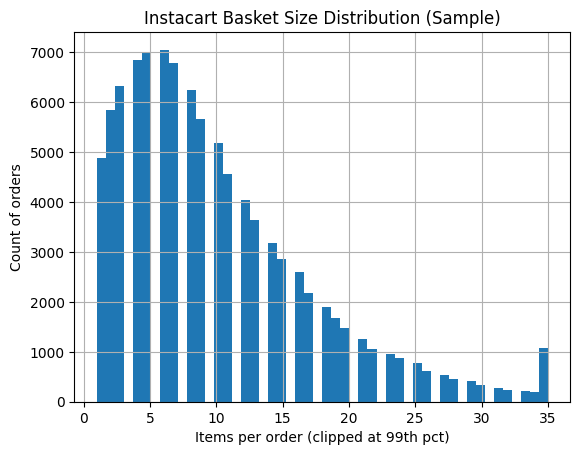

In [89]:
md("## D.3 — Basket Size Distribution (Sample)")

# Basket sizes from the sampled prior table
basket_sizes = instacart_prior_sample.groupby("order_id")["product_id"].size()

kv({
    "orders represented in sample": f"{basket_sizes.shape[0]:,}",
    "mean basket size": f"{basket_sizes.mean():.2f}",
    "median basket size": f"{basket_sizes.median():.0f}",
    "95th percentile": f"{basket_sizes.quantile(0.95):.0f}",
}, title="Basket size summary")

plt.figure()
basket_sizes.clip(upper=basket_sizes.quantile(0.99)).hist(bins=50)
plt.xlabel("Items per order (clipped at 99th pct)")
plt.ylabel("Count of orders")
plt.title("Instacart Basket Size Distribution (Sample)")
plt.show()


## D.4 — Product Frequency and Long-Tail

**Long-tail indicators**

| Metric                       | Value   |
|:-----------------------------|:--------|
| unique products in sample    | 35,098  |
| top-10 share of purchases    | 7.18%   |
| top-100 share of purchases   | 23.10%  |
| median purchases per product | 4       |

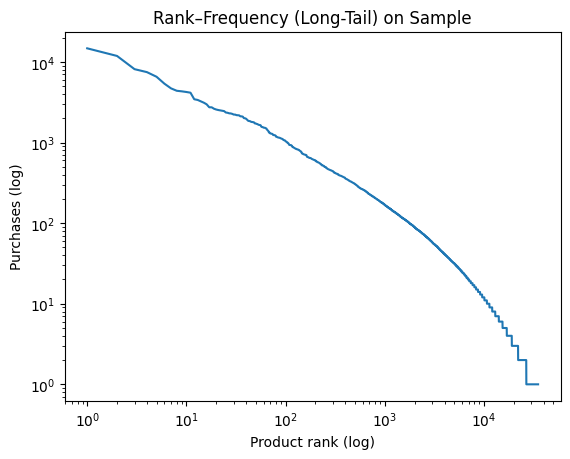

In [90]:
md("## D.4 — Product Frequency and Long-Tail")

product_freq = instacart_prior_sample["product_id"].value_counts()

# Long-tail: share of purchases contributed by top-k products
def topk_share(k):
    return product_freq.head(k).sum() / product_freq.sum()

kv({
    "unique products in sample": f"{len(product_freq):,}",
    "top-10 share of purchases": f"{topk_share(10)*100:.2f}%",
    "top-100 share of purchases": f"{topk_share(100)*100:.2f}%",
    "median purchases per product": f"{product_freq.median():.0f}",
}, title="Long-tail indicators")

# Plot rank-frequency curve (log scale)
plt.figure()
sorted_freq = product_freq.values
plt.plot(np.arange(1, len(sorted_freq)+1), sorted_freq)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Product rank (log)")
plt.ylabel("Purchases (log)")
plt.title("Rank–Frequency (Long-Tail) on Sample")
plt.show()


## D.5 — Orders per User and Sequential Structure

**Sequential feasibility**

| Metric                | Value   |
|:----------------------|:--------|
| unique users          | 206,209 |
| mean orders/user      | 16.59   |
| median orders/user    | 10      |
| users with 10+ orders | 53.70%  |

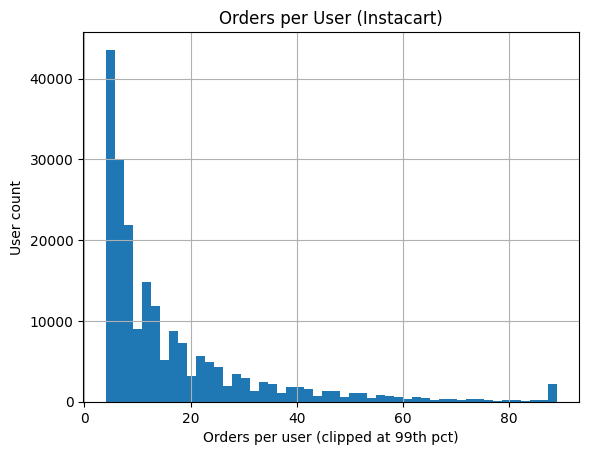

In [91]:
md("## D.5 — Orders per User and Sequential Structure")

orders_per_user = instacart_orders.groupby("user_id")["order_id"].nunique()

kv({
    "unique users": f"{orders_per_user.shape[0]:,}",
    "mean orders/user": f"{orders_per_user.mean():.2f}",
    "median orders/user": f"{orders_per_user.median():.0f}",
    "users with 10+ orders": f"{(orders_per_user>=10).mean()*100:.2f}%",
}, title="Sequential feasibility")

plt.figure()
orders_per_user.clip(upper=orders_per_user.quantile(0.99)).hist(bins=50)
plt.xlabel("Orders per user (clipped at 99th pct)")
plt.ylabel("User count")
plt.title("Orders per User (Instacart)")
plt.show()


## D.6 — Temporal Features (Day of Week / Hour)

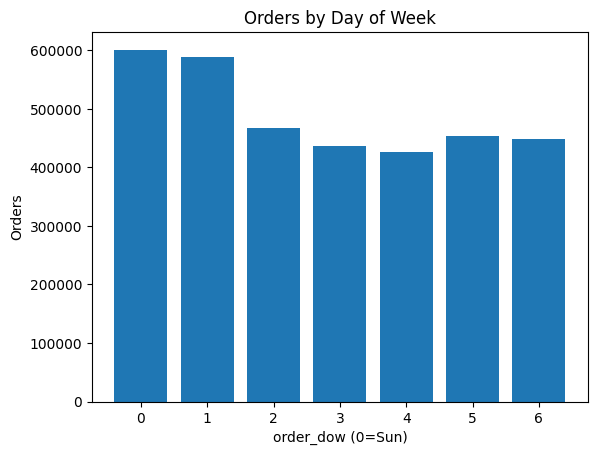

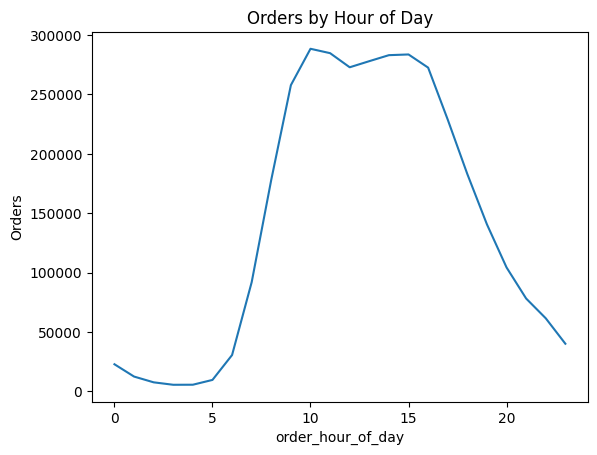

In [92]:
md("## D.6 — Temporal Features (Day of Week / Hour)")

dow_counts = instacart_orders["order_dow"].value_counts().sort_index()
hour_counts = instacart_orders["order_hour_of_day"].value_counts().sort_index()

fig = plt.figure()
plt.bar(dow_counts.index, dow_counts.values)
plt.xlabel("order_dow (0=Sun)")
plt.ylabel("Orders")
plt.title("Orders by Day of Week")
plt.show()

fig = plt.figure()
plt.plot(hour_counts.index, hour_counts.values)
plt.xlabel("order_hour_of_day")
plt.ylabel("Orders")
plt.title("Orders by Hour of Day")
plt.show()


In [93]:
md("## D.7 — Join Integrity and Duplicates (Lightweight Tests)")

# 1) Ensure every product_id in prior sample exists in products table
missing_products = set(instacart_prior_sample["product_id"].unique()) - set(instacart_products["product_id"].unique())

# 2) Ensure (order_id, product_id) pairs are unique in order_products prior sample
dup_pairs = instacart_prior_sample.duplicated(subset=["order_id", "product_id"]).sum()

kv({
    "missing product_ids in catalog (should be 0)": len(missing_products),
    "duplicate (order_id, product_id) pairs in sample": int(dup_pairs),
}, title="Integrity checks")


## D.7 — Join Integrity and Duplicates (Lightweight Tests)

**Integrity checks**

| Metric                                           |   Value |
|:-------------------------------------------------|--------:|
| missing product_ids in catalog (should be 0)     |       0 |
| duplicate (order_id, product_id) pairs in sample |       0 |

In [94]:
md("## D.8 — Reorder Behavior (Sample)")

# Reorder rate in prior sample
reorder_rate = instacart_prior_sample["reordered"].mean()

# Reorder by add_to_cart_order position (optional signal)
pos_rate = (
    instacart_prior_sample.groupby("add_to_cart_order")["reordered"]
    .mean()
    .head(20)
    .reset_index()
)

kv({
    "overall reorder rate (sample)": f"{reorder_rate*100:.2f}%",
}, title="Reorder metric")

md("**Reorder rate by add-to-cart position (first 20 positions)**")
md_table(pos_rate)


## D.8 — Reorder Behavior (Sample)

**Reorder metric**

| Metric                        | Value   |
|:------------------------------|:--------|
| overall reorder rate (sample) | 59.03%  |

**Reorder rate by add-to-cart position (first 20 positions)**

|   add_to_cart_order |   reordered |
|--------------------:|------------:|
|                   1 |    0.676063 |
|                   2 |    0.677064 |
|                   3 |    0.659781 |
|                   4 |    0.640665 |
|                   5 |    0.616878 |
|                   6 |    0.602802 |
|                   7 |    0.588251 |
|                   8 |    0.573818 |
|                   9 |    0.560603 |
|                  10 |    0.551216 |
|                  11 |    0.54144  |
|                  12 |    0.53294  |
|                  13 |    0.522195 |
|                  14 |    0.514723 |
|                  15 |    0.507691 |
|                  16 |    0.500942 |
|                  17 |    0.494367 |
|                  18 |    0.492536 |
|                  19 |    0.48568  |
|                  20 |    0.476049 |

---
# (E) Initial Insights and Research Direction

Based on the exploratory analysis, three key observations emerge that shape the project direction.

## Bias & ethics notes (selected dataset)
- **User-base bias:** Instacart users are not representative of all grocery shoppers (delivery users, geography, and income can skew behavior).
- **Platform effects:** Promotions, search/ranking, and recommendation nudges can shape baskets (observational data, not causal).
- **Privacy:** Use only aggregated results; avoid any attempt to re-identify individual users.


In [95]:
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# --- Robustly locate the Instacart tables regardless of earlier variable names ---
orders_df = globals().get("orders_sample")
if orders_df is None:
    orders_df = globals().get("instacart_orders")

order_products_df = globals().get("order_products_sample")
if order_products_df is None:
    order_products_df = globals().get("instacart_prior_sample")
if order_products_df is None:
    order_products_df = globals().get("order_products_prior_sample")

# Helper: safe formatters (avoid crashing; show N/A only if truly missing)
def fmt_pct(x):
    return "N/A" if x is None or (isinstance(x, float) and np.isnan(x)) else f"{x:.0f}%"

def fmt_float(x, nd=3):
    return "N/A" if x is None or (isinstance(x, float) and np.isnan(x)) else f"{x:.{nd}f}"

def fmt_int(x):
    return "N/A" if x is None or (isinstance(x, float) and np.isnan(x)) else f"{int(x):,}"

# Gini coefficient for a non-negative array of counts
def gini_from_counts(counts: np.ndarray) -> float:
    counts = np.asarray(counts, dtype=float)
    counts = counts[np.isfinite(counts)]
    counts = counts[counts >= 0]
    if counts.size == 0:
        return float("nan")
    if np.all(counts == 0):
        return 0.0
    counts = np.sort(counts)
    n = counts.size
    cum = np.cumsum(counts)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

# ----------------------------
# Compute Key Findings Metrics
# ----------------------------
top10_share = float("nan")
gini_coef = float("nan")
orders_min = float("nan")
orders_mean = float("nan")
reorder_rate = float("nan")
dow_peak = None
median_gap = float("nan")

# 1) Long-tail (product frequency)
if isinstance(order_products_df, pd.DataFrame) and "product_id" in order_products_df.columns and len(order_products_df) > 0:
    prod_counts = order_products_df["product_id"].value_counts(dropna=True)
    total = float(prod_counts.sum())
    n_prod = int(len(prod_counts))
    k = max(1, int(np.ceil(0.10 * n_prod)))
    top10_share = (prod_counts.iloc[:k].sum() / total) * 100.0 if total > 0 else float("nan")
    gini_coef = gini_from_counts(prod_counts.values)

# 2) Sequential structure (orders per user + reorder rate)
if isinstance(orders_df, pd.DataFrame) and "user_id" in orders_df.columns and len(orders_df) > 0:
    orders_per_user = orders_df.groupby("user_id", sort=False).size()
    orders_min = float(orders_per_user.min())
    orders_mean = float(orders_per_user.mean())

if isinstance(order_products_df, pd.DataFrame) and "reordered" in order_products_df.columns and len(order_products_df) > 0:
    # reordered is 0/1; mean is % reorders among sampled prior lines
    reorder_rate = float(order_products_df["reordered"].mean() * 100.0)

# 3) Temporal regularity (peak DOW + median inter-order gap)
if isinstance(orders_df, pd.DataFrame) and "order_dow" in orders_df.columns and len(orders_df) > 0:
    dow_counts = orders_df["order_dow"].value_counts(dropna=True)
    if len(dow_counts) > 0:
        dow_peak = int(dow_counts.idxmax())

if isinstance(orders_df, pd.DataFrame) and "days_since_prior_order" in orders_df.columns:
    gaps = orders_df["days_since_prior_order"].dropna()
    if len(gaps) > 0:
        median_gap = float(gaps.median())

dow_labels = {0:"Sunday",1:"Monday",2:"Tuesday",3:"Wednesday",4:"Thursday",5:"Friday",6:"Saturday"}
dow_peak_s = "N/A" if dow_peak is None else f"{dow_labels.get(dow_peak, str(dow_peak))} ({dow_peak})"

key_findings_md = f"""
## Key findings (from the selected Instacart dataset)

1) **Long-tail product distribution**  
- Top 10% of products account for **{fmt_pct(top10_share)}** of purchases (sample-based).  
- Gini coefficient of product frequency: **{fmt_float(gini_coef, 3)}** (higher = more inequality).  
**Implication:** High support thresholds will mostly surface obvious items; interesting patterns likely require lower support plus interestingness metrics (lift/conviction).

2) **Strong sequential structure**  
- Orders per user: min **{fmt_int(orders_min)}**, mean **{fmt_float(orders_mean, 1)}**.  
- Reorder rate: **{fmt_float(reorder_rate, 1)}%** of sampled prior-line items are marked as reorders.  
**Implication:** Unordered itemsets miss temporal “next-basket” structure; sequential pattern mining (e.g., PrefixSpan) is a good beyond-course technique.

3) **Temporal regularity**  
- Peak order day-of-week: **{dow_peak_s}** (dataset uses 0=Sunday).  
- Median inter-order gap: **{fmt_float(median_gap, 1)}** days (excluding first orders).  
**Implication:** Patterns likely differ by weekday/hour; segmentation is a natural extension.

### Initial research questions
- **RQ1:** How does the minimum support threshold affect rule quality and interpretability?  
  *Plan:* sweep support in `[0.001, 0.01, 0.05, 0.10]`, compare lift/conviction and the “obviousness” of top rules.
- **RQ2:** Do sequential patterns reveal structure missed by frequent itemsets?  
  *Plan:* run PrefixSpan on per-user order sequences and compare to standard itemsets.
- **RQ3:** How do temporal segments (day-of-week / hour) change discovered patterns?  
  *Plan:* segment by day-of-week and hour-of-day and compare top rules/patterns.
"""

display(Markdown(key_findings_md))



## Key findings (from the selected Instacart dataset)

1) **Long-tail product distribution**  
- Top 10% of products account for **76%** of purchases (sample-based).  
- Gini coefficient of product frequency: **0.830** (higher = more inequality).  
**Implication:** High support thresholds will mostly surface obvious items; interesting patterns likely require lower support plus interestingness metrics (lift/conviction).

2) **Strong sequential structure**  
- Orders per user: min **4**, mean **16.6**.  
- Reorder rate: **59.0%** of sampled prior-line items are marked as reorders.  
**Implication:** Unordered itemsets miss temporal “next-basket” structure; sequential pattern mining (e.g., PrefixSpan) is a good beyond-course technique.

3) **Temporal regularity**  
- Peak order day-of-week: **Sunday (0)** (dataset uses 0=Sunday).  
- Median inter-order gap: **7.0** days (excluding first orders).  
**Implication:** Patterns likely differ by weekday/hour; segmentation is a natural extension.

### Initial research questions
- **RQ1:** How does the minimum support threshold affect rule quality and interpretability?  
  *Plan:* sweep support in `[0.001, 0.01, 0.05, 0.10]`, compare lift/conviction and the “obviousness” of top rules.
- **RQ2:** Do sequential patterns reveal structure missed by frequent itemsets?  
  *Plan:* run PrefixSpan on per-user order sequences and compare to standard itemsets.
- **RQ3:** How do temporal segments (day-of-week / hour) change discovered patterns?  
  *Plan:* segment by day-of-week and hour-of-day and compare top rules/patterns.


---
# (F) GitHub Portfolio

**Repository:** https://github.com/ahadh76221/csce676-data-mining-project

**Repository structure:**
```
project-repo/
├── README.md              # Project overview, setup instructions
├── notebooks/
│   └── checkpoint_1.ipynb # This notebook
├── src/                   # (Future) Source code
├── data/                  # (gitignored) Local data
└── .gitignore
```

---
# Tests

Validate non-trivial behavior of data processing.

In [97]:
from IPython.display import Markdown, display

display(Markdown("## Tests (sanity checks)"))

# ============================================================
# TESTS
# ============================================================

def test_no_duplicate_order_product_pairs():
    """Each (order_id, product_id) pair should appear at most once."""
    dups = instacart_prior_sample.duplicated(subset=['order_id', 'product_id']).sum()
    assert dups == 0, f"Found {dups} duplicate (order_id, product_id) pairs"
    print("✅ test_no_duplicate_order_product_pairs passed")

def test_orders_have_valid_user_ids():
    """All orders should have valid user IDs."""
    null_users = instacart_orders['user_id'].isnull().sum()
    assert null_users == 0, f"Found {null_users} orders with null user_id"
    print("✅ test_orders_have_valid_user_ids passed")

def test_product_ids_exist_in_products_table():
    """All product_ids in orders should exist in products table."""
    order_products = set(instacart_prior_sample['product_id'].unique())
    known_products = set(instacart_products['product_id'].unique())
    unknown = order_products - known_products
    assert len(unknown) == 0, f"Found {len(unknown)} unknown product IDs"
    print("✅ test_product_ids_exist_in_products_table passed")

def test_order_numbers_are_sequential():
    """For each user, order_number should start at 1 and increment."""
    # Sample 1000 users for efficiency
    sample_users = instacart_orders['user_id'].drop_duplicates().sample(1000, random_state=42)
    for uid in sample_users:
        user_orders = instacart_orders[instacart_orders['user_id'] == uid]['order_number'].sort_values()
        expected = list(range(1, len(user_orders) + 1))
        assert list(user_orders) == expected, f"User {uid} has non-sequential order numbers"
    print("✅ test_order_numbers_are_sequential passed (sampled 1000 users)")

def test_basket_sizes_are_positive():
    """All baskets should have at least 1 item."""
    basket_sizes = instacart_prior_sample.groupby('order_id').size()
    assert (basket_sizes >= 1).all(), "Found baskets with 0 items"
    print("✅ test_basket_sizes_are_positive passed")

# Run all tests
test_no_duplicate_order_product_pairs()
test_orders_have_valid_user_ids()
test_product_ids_exist_in_products_table()
test_order_numbers_are_sequential()
test_basket_sizes_are_positive()

print("\n" + "="*60)
print("ALL TESTS PASSED ✅")


## Tests (sanity checks)

✅ test_no_duplicate_order_product_pairs passed
✅ test_orders_have_valid_user_ids passed
✅ test_product_ids_exist_in_products_table passed
✅ test_order_numbers_are_sequential passed (sampled 1000 users)
✅ test_basket_sizes_are_positive passed

ALL TESTS PASSED ✅
